# Alby



數據解讀重點 (Insight)
根據你之前的輸出：

進攻核心 (RC & GPA)：FERRIS 的 RC 高達 11.176，是隊伍中創造得分能力最強的球員。

擊球運氣/品質 (BABIP)：ANDREASSON 的 BABIP 為 0.800，這是一個極端數據。這代表他擊出的場內球幾乎都形成安打，或者他擊球力量極大，讓防守方無法處理。在你的 XGBoost 模型中，這個指標可以作為預測球員未來表現是否會「校正回歸」的關鍵特徵。

選球紀律 (K% & BB%)：FERRIS 的三振率 (k_pct) 為 0，且創造得分最高，是極其穩定的打擊者。

In [4]:
import pandas as pd
import requests
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 抓取原始數據
url = "https://stats.baseboll-softboll.se/api/v1/stats/events/2025-regionserien-baseboll/index?section=players&stats-section=batting&team=&round=&split=&split=&language=en"
headers_api = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36',
    'Accept': 'application/json'
}

try:
    response = requests.get(url, headers=headers_api)
    data = response.json()
    df_stats = pd.json_normalize(data['data'], sep='_')
    print("內部數據的實際欄位：")
    print(df_stats.columns.tolist())

    # 確保數值欄位型態正確
    numeric_cols = ['ab', 'h', 'hr', 'so', 'sf', 'bb', 'hbp', 'sh', 'tb', 'slg', 'avg', 'obp', 'ops']
    for col in numeric_cols:
        df_stats[col] = pd.to_numeric(df_stats[col], errors='coerce').fillna(0)

    # 2. 篩選：Stockholm B (ID: 36163) 且 打數 (AB) >= 10
    df_stats['teamid'] = df_stats['teamid'].astype(str)
    # --- 關鍵過濾行 ---
    df_sto_b = df_stats[(df_stats['teamid'] == '36162') & (df_stats['ab'] >= 10)].copy()

    # 3. 進階數據計算
    df_sto_b['pa'] = df_sto_b['ab'] + df_sto_b['bb'] + df_sto_b['hbp'] + df_sto_b['sf'] + df_sto_b['sh']
    df_sto_b['avg'] = df_sto_b['avg'] / 1000
    df_sto_b['ops'] = df_sto_b['ops'] / 1000
    df_sto_b['obp'] = df_sto_b['obp'] / 1000
    df_sto_b['slg'] = df_sto_b['slg'] / 1000
    
    def safe_divide(numerator, denominator):
        return np.where(denominator == 0, 0, numerator / denominator)

    # 計算 BABIP, ISO, K%, BB%, RC, GPA
    babip_denom = df_sto_b['ab'] - df_sto_b['so'] - df_sto_b['hr'] + df_sto_b['sf']
    df_sto_b['babip'] = safe_divide(df_sto_b['h'] - df_sto_b['hr'], babip_denom)
    df_sto_b['iso_val'] = (df_sto_b['slg'] - df_sto_b['avg']) 
    df_sto_b['k_pct'] = safe_divide(df_sto_b['so'], df_sto_b['pa'])
    df_sto_b['bb_pct'] = safe_divide(df_sto_b['bb'], df_sto_b['pa'])
    df_sto_b['rc'] = safe_divide((df_sto_b['h'] + df_sto_b['bb']) * df_sto_b['tb'], (df_sto_b['ab'] + df_sto_b['bb']))
    df_sto_b['gpa_val'] = (1.8 * (df_sto_b['obp']) + (df_sto_b['slg'])) / 4

    # 4. 清理球員姓名 (移除 HTML 標籤)
    def clean_name(text):
        return " ".join(re.sub(r'<[^>]*>', ' ', text).split())
    df_sto_b['name_clean'] = df_sto_b['name'].apply(clean_name)

except Exception as e:
    print(f"分析執行出錯: {e}")

內部數據的實際欄位：
['g', 'gs', 'ab', 'r', 'h', 'double', 'triple', 'hr', 'rbi', 'tb', 'avg', 'slg', 'obp', 'ops', 'bb', 'hbp', 'so', 'gdp', 'sf', 'sh', 'sb', 'cs', 'link', 'name', 'teamcode', 'teamid']


In [5]:
# 挑選想要輸出的欄位
output_columns = [
    'name_clean', 'ab', 'h','avg', 'ops', 'babip', 'iso_val', 
    'k_pct', 'bb_pct', 'rc', 'gpa_val'
]

# 根據 GPA 排行 (也可以改為 rc)，並取前 10 名
top_players = df_sto_b.sort_values(by='gpa_val', ascending=False)[output_columns]

print("=== Stockholm B 進階數據排行榜 (Top GPA) [AB>=10] ===")
# 使用 round(3) 讓小數點保持三位
print(top_players.round(2).to_string(index=False))

=== Stockholm B 進階數據排行榜 (Top GPA) [AB>=10] ===
                   name_clean  ab  h  avg  ops  babip  iso_val  k_pct  bb_pct    rc  gpa_val
CENTERO LUMIZ Eliezer Pollyto  46 19 0.41 1.25   0.42     0.26   0.04    0.25 17.71     0.43
              VASQUEZ Gabriel  11  6 0.55 1.13   0.55     0.00   0.00    0.00  3.27     0.40
                 FLORES Billy  16  7 0.44 1.12   0.44     0.19   0.00    0.06  4.71     0.38
             GUTIERREZ Wilman  47 19 0.40 1.08   0.42     0.13   0.03    0.16 12.72     0.38
               SUAREZ Abraham  24 10 0.42 1.02   0.50     0.04   0.12    0.19  5.87     0.37
                 MEJIA Leonel  29 11 0.38 0.98   0.42     0.10   0.11    0.08  6.12     0.35
                   YANEZ Luis  29 11 0.38 0.97   0.41     0.10   0.06    0.17  6.80     0.34
                CRUZ Dionisio  11  5 0.46 0.96   0.50     0.00   0.08    0.08  2.50     0.34
                   REYES Alex  42 15 0.36 0.90   0.38     0.07   0.09    0.18  8.65     0.32
              MARTINEZ 

C:\Users\dechihao\AppData\Local\Temp\ipykernel_10408\2966312561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rc, x='rc', y='name_clean', palette='viridis')


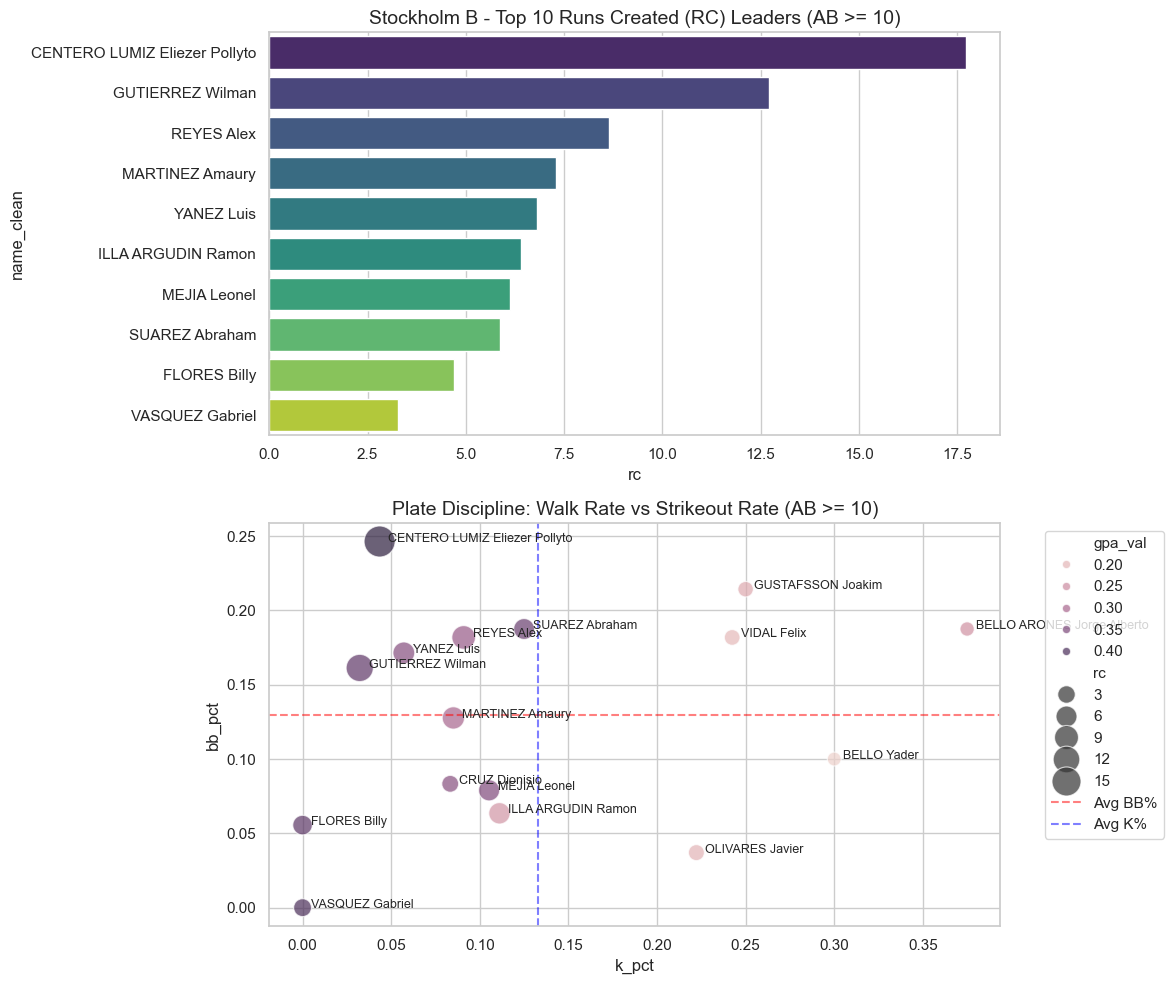

In [6]:
# 6. 視覺化分析
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))
# A. 創造得分 (RC) 排行
plt.subplot(2, 1, 1)
top_rc = df_sto_b.sort_values('rc', ascending=False).head(10)
sns.barplot(data=top_rc, x='rc', y='name_clean', palette='viridis')
plt.title('Stockholm B - Top 10 Runs Created (RC) Leaders (AB >= 10)', fontsize=14)
# B. 選球紀律分析 (K% vs BB%)
plt.subplot(2, 1, 2)
sns.scatterplot(data=df_sto_b, x='k_pct', y='bb_pct', size='rc', hue='gpa_val', sizes=(100, 500), alpha=0.7)
plt.axhline(df_sto_b['bb_pct'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg BB%')
plt.axvline(df_sto_b['k_pct'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg K%')

    # 標註球員姓名
for i in range(len(df_sto_b)):
    plt.text(df_sto_b.iloc[i]['k_pct']+0.005, df_sto_b.iloc[i]['bb_pct'], df_sto_b.iloc[i]['name_clean'], fontsize=9)

plt.title('Plate Discipline: Walk Rate vs Strikeout Rate (AB >= 10)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()